# 61 — LSEG/Gemma hybrid long-leg sector-control component decomposition

**Question.** Does Notebook 60's selected-long advantage over its matched same-sector basket accrue from the entry open to the same-session close, or from that close to the following open?

The design was frozen in `frozen_specs/lseg_gemma_hybrid_long_leg_sector_component_v1.json` before either component outcome was computed. The Notebook 36 signal dates and selected long weights, Notebook 60 sector control, original 33, and open-to-open interval remain unchanged. This is a post-result gross accounting diagnostic on an opened window—not an exit search, a new strategy, or alpha validation. Licensed headline text is neither loaded nor emitted.

In [1]:
from __future__ import annotations

import hashlib
import json
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from statsmodels.stats.multitest import multipletests

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == 'final_experiments':
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from final_experiments.lib.evaluate import annualized_sharpe  # noqa: E402
from final_experiments.lib.plots import CATEGORICAL, INK, apply_house_style  # noqa: E402
from final_experiments.lib.risk_overlay import paired_block_bootstrap_difference  # noqa: E402
from final_experiments.lib.sector_portfolios import SECTOR_MEMBERS  # noqa: E402
from final_experiments.lib.sparse_spread import build_exact_extrema_targets  # noqa: E402

SPEC_PATH = REPO_ROOT / 'final_experiments/frozen_specs/lseg_gemma_hybrid_long_leg_sector_component_v1.json'
AGGREGATE_DIR = REPO_ROOT / 'final_experiments/outputs/13_lseg_44_gemma_robustness'
GEMMA_PATH = AGGREGATE_DIR / 'gemma4_26b_firm_open_aggregators.parquet'
FINBERT_PATH = AGGREGATE_DIR / 'finbert_firm_open_aggregators.parquet'
PRICE_PATH = REPO_ROOT / 'Data/derived/prices/lseg_us_sector_33_8m.csv'
PRICE_MANIFEST_PATH = REPO_ROOT / 'Data/derived/prices/lseg_us_sector_33_8m.manifest.json'
NOTEBOOK60_DAILY_PATH = REPO_ROOT / 'final_experiments/outputs/60_lseg_gemma_hybrid_long_leg_exposure_control/daily_control_audit.parquet'
OUTPUT_DIR = REPO_ROOT / 'final_experiments/outputs/61_lseg_gemma_hybrid_long_leg_sector_component'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

spec = json.loads(SPEC_PATH.read_text())
assert spec['status'] == 'frozen_before_component_outcomes'
SEED = int(spec['inference']['seed'])
BLOCK_LENGTH = int(spec['inference']['block_length_sessions'])
REPLICATIONS = int(spec['inference']['replications'])
BH_Q = float(spec['inference']['bh_q'])
SINGLE_NAME_CAP = 0.25
IDENTITY_TOLERANCE = float(spec['decomposition']['identity_tolerance'])
apply_house_style()
pd.set_option('display.max_columns', 80)
pd.set_option('display.float_format', lambda value: f'{value:,.6f}')

## Reconstruct the unchanged selected and same-sector weights

For each stock, entry-open-to-close plus close-to-next-open is exactly the existing open-to-open return when both pieces use the entry open as denominator. Applying the selected-minus-sector-control weight difference to those two pieces must reproduce Notebook 60's total gross difference within `1e-12`.

In [2]:
sector_members = {sector: tuple(members[:3]) for sector, members in SECTOR_MEMBERS.items()}
original_symbols = tuple(symbol for members in sector_members.values() for symbol in members)
symbols = tuple(sorted(original_symbols))
if len(symbols) != 33 or len(sector_members) != 11 or any(len(members) != 3 for members in sector_members.values()):
    raise ValueError('expected immutable original 33 in eleven three-company sectors')

gemma = pd.read_parquet(GEMMA_PATH)
finbert = pd.read_parquet(FINBERT_PATH)
for frame in (gemma, finbert):
    frame['session_date'] = pd.to_datetime(frame['session_date']).dt.normalize()
gemma = gemma.loc[gemma['symbol'].isin(symbols)].copy()
finbert = finbert.loc[finbert['symbol'].isin(symbols)].copy()
if not gemma[['session_date', 'symbol']].equals(finbert[['session_date', 'symbol']]):
    raise ValueError('paired scorer panels are not row-aligned')
if gemma.duplicated(['session_date', 'symbol']).any() or finbert['strongest_event'].isna().any():
    raise ValueError('candidate scorer input is invalid')
sessions = pd.DatetimeIndex(sorted(gemma['session_date'].unique()))
if len(sessions) != 167 or set(gemma['symbol'].unique()) != set(symbols):
    raise ValueError('expected 167 sessions and immutable original 33')

prices = pd.read_csv(PRICE_PATH, parse_dates=['session_date'])
prices['session_date'] = pd.to_datetime(prices['session_date']).dt.normalize()
prices = prices.loc[prices['symbol'].isin(symbols)].copy()
price_manifest = json.loads(PRICE_MANIFEST_PATH.read_text())
assert price_manifest['return_convention'] == 'split-adjusted price returns; dividends not back-adjusted'
assert hashlib.sha256(PRICE_PATH.read_bytes()).hexdigest() == price_manifest['file']['sha256']
open_wide = prices.pivot(index='session_date', columns='symbol', values='open').sort_index().dropna()
close_wide = prices.pivot(index='session_date', columns='symbol', values='close').sort_index().reindex(open_wide.index)
locations = open_wide.index.get_indexer(sessions)
if (locations < 0).any() or not np.array_equal(locations[1:], locations[:-1] + 1):
    raise ValueError('signal sessions are not consecutive complete-price sessions')
if locations[-1] + 1 >= len(open_wide):
    raise ValueError('last signal session has no following open')
next_sessions = open_wide.index[locations + 1]
current_open = open_wide.loc[sessions, list(symbols)].to_numpy(dtype=float)
current_close = close_wide.loc[sessions, list(symbols)].to_numpy(dtype=float)
next_open = open_wide.loc[next_sessions, list(symbols)].to_numpy(dtype=float)
if not np.isfinite(np.stack([current_open, current_close, next_open])).all():
    raise ValueError('component prices must be complete')
intraday_stock = current_close / current_open - 1.0
overnight_stock = (next_open - current_close) / current_open
open_to_open_stock = next_open / current_open - 1.0
stock_identity_error = float(np.max(np.abs(intraday_stock + overnight_stock - open_to_open_stock)))

def rank_map(frame: pd.DataFrame) -> dict[pd.Timestamp, tuple[str, ...]]:
    result = {
        pd.Timestamp(session): tuple(
            day.sort_values(['strongest_event', 'symbol'], ascending=[False, True], kind='mergesort')['symbol']
        )
        for session, day in frame.groupby('session_date', sort=True)
    }
    if len(result) != len(sessions) or any(set(row) != set(symbols) for row in result.values()):
        raise ValueError('rank map is incomplete')
    return result

_, target_audit = build_exact_extrema_targets(gemma, single_name_cap=SINGLE_NAME_CAP)
if not np.array_equal(pd.to_datetime(target_audit['session_date']).to_numpy(), sessions.to_numpy()):
    raise ValueError('target audit is not aligned to the session spine')
ranks = rank_map(finbert)
symbol_index = {symbol: index for index, symbol in enumerate(symbols)}
selected_weights = np.zeros((len(sessions), len(symbols)), dtype=float)
for row_index, row in enumerate(target_audit.itertuples(index=False)):
    n_long, n_short, eligible = int(row.positive_names), int(row.negative_names), bool(row.eligible)
    if not eligible:
        continue
    ranked = ranks[pd.Timestamp(row.session_date)]
    long_symbols = ranked[:n_long]
    short_symbols = ranked[-n_short:]
    if not n_long or not n_short or set(long_symbols) & set(short_symbols):
        raise RuntimeError('invalid hybrid rank selection')
    leg_exposure = min(0.5, SINGLE_NAME_CAP * n_long, SINGLE_NAME_CAP * n_short)
    for symbol in long_symbols:
        selected_weights[row_index, symbol_index[symbol]] = leg_exposure / n_long
if selected_weights.min() < 0 or selected_weights.max() > SINGLE_NAME_CAP + IDENTITY_TOLERANCE:
    raise RuntimeError('selected long weights violate the frozen bounds')

sector_weights = np.zeros_like(selected_weights)
sector_exposure_errors = []
for sector, members in sector_members.items():
    indices = np.array([symbol_index[symbol] for symbol in members], dtype=int)
    exposure = selected_weights[:, indices].sum(axis=1)
    sector_weights[:, indices] = exposure[:, None] / len(indices)
    sector_exposure_errors.append(np.abs(sector_weights[:, indices].sum(axis=1) - exposure))
total_exposure_error = float(np.abs(sector_weights.sum(axis=1) - selected_weights.sum(axis=1)).max())
sector_exposure_error = float(np.concatenate(sector_exposure_errors).max())
if max(total_exposure_error, sector_exposure_error) > IDENTITY_TOLERANCE:
    raise RuntimeError('same-sector control exposure matching failed')

selected_intraday = np.sum(selected_weights * intraday_stock, axis=1)
control_intraday = np.sum(sector_weights * intraday_stock, axis=1)
selected_overnight = np.sum(selected_weights * overnight_stock, axis=1)
control_overnight = np.sum(sector_weights * overnight_stock, axis=1)
intraday_difference = selected_intraday - control_intraday
overnight_difference = selected_overnight - control_overnight
total_difference = intraday_difference + overnight_difference

n60 = pd.read_parquet(NOTEBOOK60_DAILY_PATH).reset_index(drop=True)
n60['session_date'] = pd.to_datetime(n60['session_date']).dt.normalize()
if not np.array_equal(n60['session_date'].to_numpy(), sessions.to_numpy()):
    raise ValueError('Notebook 60 daily path is not aligned')
selected_total = selected_intraday + selected_overnight
control_total = control_intraday + control_overnight
selected_identity_error = float(np.max(np.abs(selected_total - n60['selected_long_gross_contribution'].to_numpy(dtype=float))))
control_identity_error = float(np.max(np.abs(control_total - n60['same_sector_equal_weight_gross_contribution'].to_numpy(dtype=float))))
difference_identity_error = float(np.max(np.abs(total_difference - n60['selected_minus_same_sector'].to_numpy(dtype=float))))
if max(stock_identity_error, selected_identity_error, control_identity_error, difference_identity_error) > IDENTITY_TOLERANCE:
    raise RuntimeError('component decomposition identity failed')

daily = pd.DataFrame({
    'session_date': sessions, 'return_end_date': next_sessions,
    'selected_intraday': selected_intraday, 'control_intraday': control_intraday,
    'intraday_difference': intraday_difference,
    'selected_overnight': selected_overnight, 'control_overnight': control_overnight,
    'overnight_difference': overnight_difference,
    'total_difference': total_difference,
    'long_gross_exposure': selected_weights.sum(axis=1),
})
daily['active'] = daily['long_gross_exposure'].gt(0)
identity = pd.DataFrame([{
    'stock_component_max_error': stock_identity_error,
    'selected_total_vs_notebook60_max_error': selected_identity_error,
    'control_total_vs_notebook60_max_error': control_identity_error,
    'component_difference_vs_notebook60_max_error': difference_identity_error,
    'matched_total_long_exposure_max_error': total_exposure_error,
    'matched_sector_exposure_max_error': sector_exposure_error,
    'sessions': len(daily), 'active_sessions': int(daily['active'].sum()),
    'companies': len(symbols), 'sectors': len(sector_members),
    'licensed_headline_text_loaded': False,
}])
display(identity.T)

,0
stock_component_max_error,0.000000
selected_total_vs_notebook60_max_error,0.000000
control_total_vs_notebook60_max_error,0.000000
component_difference_vs_notebook60_max_error,0.000000
matched_total_long_exposure_max_error,0.000000
matched_sector_exposure_max_error,0.000000
sessions,167
active_sessions,70
companies,33
sectors,11


## Frozen two-component inference family

The intraday and overnight selected-minus-sector-control differences are each tested against zero over all 167 complete sessions with the predeclared five-session circular moving-block bootstrap. Benjamini–Hochberg corrects the two tests. Component path summaries and chronological halves are descriptive.

In [3]:
component_columns = {
    'intraday': ('selected_intraday', 'control_intraday', 'intraday_difference'),
    'overnight': ('selected_overnight', 'control_overnight', 'overnight_difference'),
}
cash = daily[['session_date']].copy()
cash['value'] = 0.0
split = (len(daily) + 1) // 2
total_sum = float(daily['total_difference'].sum())
inference_rows = []
for component, (selected_column, control_column, difference_column) in component_columns.items():
    difference_frame = daily[['session_date', difference_column]].rename(columns={difference_column: 'value'})
    inference = paired_block_bootstrap_difference(
        difference_frame, cash, value_col='value', block_length=BLOCK_LENGTH,
        replications=REPLICATIONS, seed=SEED,
    )
    difference = daily[difference_column].to_numpy(dtype=float)
    inference_rows.append({
        'component': component,
        'selected_mean_bps_session': float(daily[selected_column].mean() * 10_000),
        'control_mean_bps_session': float(daily[control_column].mean() * 10_000),
        'mean_difference_bps_session': float(difference.mean() * 10_000),
        'ci_low_bps_session': float(inference['ci_low'] * 10_000),
        'ci_high_bps_session': float(inference['ci_high'] * 10_000),
        'p_two_sided': float(inference['p_two_sided']),
        'difference_sharpe_all_sessions': float(annualized_sharpe(pd.Series(difference))),
        'mean_difference_bps_active_session': float(daily.loc[daily['active'], difference_column].mean() * 10_000),
        'first_half_mean_difference_bps_session': float(difference[:split].mean() * 10_000),
        'second_half_mean_difference_bps_session': float(difference[split:].mean() * 10_000),
        'first_half_difference_sharpe': float(annualized_sharpe(pd.Series(difference[:split]))),
        'second_half_difference_sharpe': float(annualized_sharpe(pd.Series(difference[split:]))),
        'arithmetic_total_difference': float(difference.sum()),
        'share_of_total_difference_sum': float(difference.sum() / total_sum),
    })
inference_table = pd.DataFrame(inference_rows)
reject, q_values, _, _ = multipletests(inference_table['p_two_sided'], alpha=BH_Q, method='fdr_bh')
inference_table['bh_q_value'] = q_values
inference_table['bh_reject'] = reject
inference_table['positive_gate'] = inference_table['mean_difference_bps_session'].gt(0) & inference_table['bh_reject']
indexed = inference_table.set_index('component')
intraday_pass = bool(indexed.loc['intraday', 'positive_gate'])
overnight_pass = bool(indexed.loc['overnight', 'positive_gate'])
mechanism_class = (
    'both' if intraday_pass and overnight_pass else
    'intraday_only' if intraday_pass else
    'overnight_only' if overnight_pass else
    'neither'
)
path_summary_rows = []
for path, columns in {
    'selected_long': ('selected_intraday', 'selected_overnight'),
    'same_sector_control': ('control_intraday', 'control_overnight'),
}.items():
    for component, column in zip(('intraday', 'overnight'), columns, strict=True):
        values = daily[column].to_numpy(dtype=float)
        path_summary_rows.append({
            'path': path, 'component': component,
            'mean_bps_session': float(values.mean() * 10_000),
            'sharpe_all_sessions': float(annualized_sharpe(pd.Series(values))),
            'first_half_sharpe': float(annualized_sharpe(pd.Series(values[:split]))),
            'second_half_sharpe': float(annualized_sharpe(pd.Series(values[split:]))),
            'arithmetic_total_contribution': float(values.sum()),
        })
path_summary = pd.DataFrame(path_summary_rows)
display(path_summary)
display(inference_table)
print('Frozen mechanism classification:', mechanism_class)

,path,component,mean_bps_session,sharpe_all_sessions,first_half_sharpe,second_half_sharpe,arithmetic_total_contribution
0,selected_long,intraday,6.345788,4.096223,3.233437,4.832501,0.105975
1,selected_long,overnight,4.632104,2.333123,3.784241,-0.043979,0.077356
2,same_sector_control,intraday,4.891731,3.424428,3.249697,3.725577,0.081692
3,same_sector_control,overnight,2.424228,2.079034,3.612228,0.285536,0.040485


,component,selected_mean_bps_session,control_mean_bps_session,mean_difference_bps_session,ci_low_bps_session,ci_high_bps_session,p_two_sided,difference_sharpe_all_sessions,mean_difference_bps_active_session,first_half_mean_difference_bps_session,second_half_mean_difference_bps_session,first_half_difference_sharpe,second_half_difference_sharpe,arithmetic_total_difference,share_of_total_difference_sum,bh_q_value,bh_reject,positive_gate
0,intraday,6.345788,4.891731,1.454057,-0.324358,3.398614,0.126400,1.797783,3.468965,0.574542,2.344169,1.186882,2.254870,0.024283,0.397074,0.126400,False,False
1,overnight,4.632104,2.424228,2.207876,-0.005657,4.845212,0.075600,2.152348,5.267361,4.746897,-0.361736,3.598026,-0.643839,0.036872,0.602926,0.126400,False,False


Frozen mechanism classification: neither


## Results, figures, and persisted evidence

Cumulative lines are arithmetic gross differences because the two components are exactly additive. Neither component is treated as a separately executable or costed strategy return.

findfont: Failed to find font weight medium, now using 400.


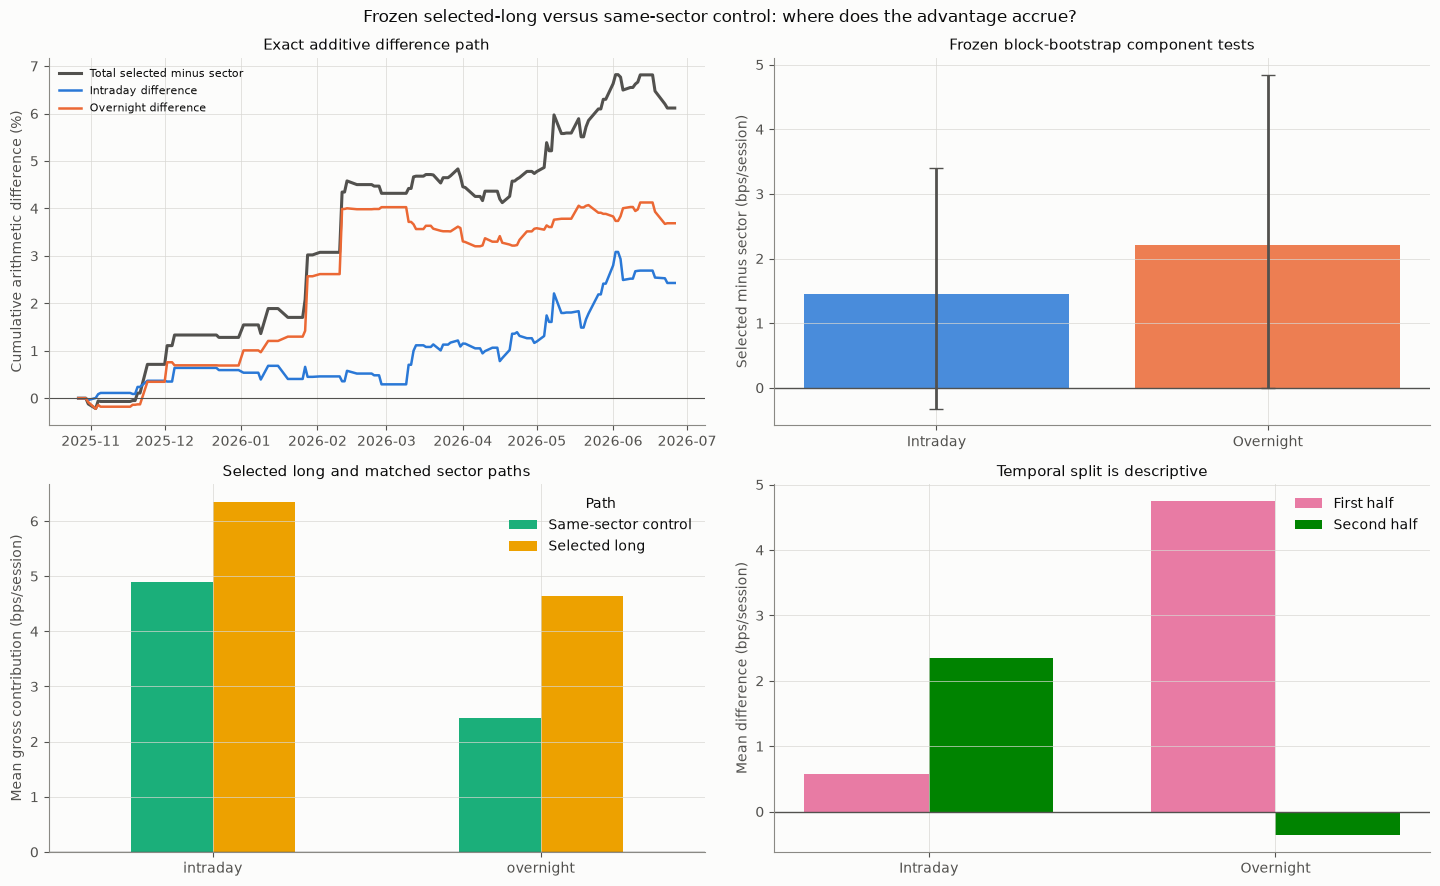

### Decision

- Intraday selected minus sector is **+1.45 bps/session** [-0.32, +3.40], BH q=**0.1264**.
- Overnight selected minus sector is **+2.21 bps/session** [-0.01, +4.85], BH q=**0.1264**.
- Frozen mechanism classification: **neither**. This does not select an exit, create a component strategy, change the prospective contract, or validate alpha.

{
  "mechanism_class": "neither",
  "intraday_selected_minus_sector_positive_gate": false,
  "overnight_selected_minus_sector_positive_gate": false,
  "intraday_difference_bps_session": 1.454057062136841,
  "intraday_difference_ci_low_bps_session": -0.32435826401325446,
  "intraday_difference_ci_high_bps_session": 3.398613857154177,
  "intraday_difference_bh_q": 0.1264,
  "intraday_share_of_total_difference_sum": 0.3970736677818183,
  "overnight_difference_bps_session": 2.2078756725611637,
  "overnight_difference_ci_low_bps_session": -0.0056568994634117985,
  "overnight_difference_ci_high_bps_session": 4.845211518250972,
  "overnight_difference_bh_q": 0.1264,
  "overnight_share_of_total_difference_sum": 0.6029263322181816,
  "alternative_exit_return_constructed": false,
  "new_traded_strategy_constructed": false,
  "cost_or_turnover_comparison_constructed": false,
  "prospective_contract_changed": false,
  "validated_alpha": false,
  "deployment_qualified": false
}


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14.5, 9.0))
axes[0, 0].plot(daily['session_date'], 100 * daily['total_difference'].cumsum(), color=INK['reference'], lw=2.2, label='Total selected minus sector')
axes[0, 0].plot(daily['session_date'], 100 * daily['intraday_difference'].cumsum(), color=CATEGORICAL[0], lw=1.8, label='Intraday difference')
axes[0, 0].plot(daily['session_date'], 100 * daily['overnight_difference'].cumsum(), color=CATEGORICAL[1], lw=1.8, label='Overnight difference')
axes[0, 0].axhline(0, color=INK['reference'], lw=0.8)
axes[0, 0].set_ylabel('Cumulative arithmetic difference (%)')
axes[0, 0].set_title('Exact additive difference path')
axes[0, 0].legend(frameon=False, fontsize=8)

x = np.arange(len(inference_table))
means = inference_table['mean_difference_bps_session'].to_numpy(dtype=float)
lower = means - inference_table['ci_low_bps_session'].to_numpy(dtype=float)
upper = inference_table['ci_high_bps_session'].to_numpy(dtype=float) - means
axes[0, 1].bar(x, means, color=CATEGORICAL[:2], alpha=0.85)
axes[0, 1].errorbar(x, means, yerr=np.vstack([lower, upper]), fmt='none', color=INK['reference'], capsize=5)
axes[0, 1].axhline(0, color=INK['reference'], lw=1)
axes[0, 1].set_xticks(x, inference_table['component'].str.title())
axes[0, 1].set_ylabel('Selected minus sector (bps/session)')
axes[0, 1].set_title('Frozen block-bootstrap component tests')

summary_pivot = (
    path_summary.pivot(index='component', columns='path', values='mean_bps_session')
    .loc[['intraday', 'overnight']]
    .rename(columns={'selected_long': 'Selected long', 'same_sector_control': 'Same-sector control'})
)
summary_pivot.plot(kind='bar', ax=axes[1, 0], color=CATEGORICAL[2:4], rot=0)
axes[1, 0].axhline(0, color=INK['reference'], lw=1)
axes[1, 0].set_ylabel('Mean gross contribution (bps/session)')
axes[1, 0].set_xlabel('')
axes[1, 0].set_title('Selected long and matched sector paths')
axes[1, 0].legend(title='Path', frameon=False)

width = 0.36
axes[1, 1].bar(x - width / 2, inference_table['first_half_mean_difference_bps_session'], width, color=CATEGORICAL[4], label='First half')
axes[1, 1].bar(x + width / 2, inference_table['second_half_mean_difference_bps_session'], width, color=CATEGORICAL[5], label='Second half')
axes[1, 1].axhline(0, color=INK['reference'], lw=1)
axes[1, 1].set_xticks(x, inference_table['component'].str.title())
axes[1, 1].set_ylabel('Mean difference (bps/session)')
axes[1, 1].set_title('Temporal split is descriptive')
axes[1, 1].legend(frameon=False)
fig.suptitle('Frozen selected-long versus same-sector control: where does the advantage accrue?')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'long_leg_sector_component.png', dpi=180, bbox_inches='tight')
plt.show()

identity.to_csv(OUTPUT_DIR / 'identity.csv', index=False)
path_summary.to_csv(OUTPUT_DIR / 'path_component_summary.csv', index=False)
inference_table.to_csv(OUTPUT_DIR / 'component_inference.csv', index=False)
daily.to_parquet(OUTPUT_DIR / 'daily_component_audit.parquet', index=False)
intraday_row = indexed.loc['intraday']
overnight_row = indexed.loc['overnight']
decision = {
    'mechanism_class': mechanism_class,
    'intraday_selected_minus_sector_positive_gate': intraday_pass,
    'overnight_selected_minus_sector_positive_gate': overnight_pass,
    'intraday_difference_bps_session': float(intraday_row['mean_difference_bps_session']),
    'intraday_difference_ci_low_bps_session': float(intraday_row['ci_low_bps_session']),
    'intraday_difference_ci_high_bps_session': float(intraday_row['ci_high_bps_session']),
    'intraday_difference_bh_q': float(intraday_row['bh_q_value']),
    'intraday_share_of_total_difference_sum': float(intraday_row['share_of_total_difference_sum']),
    'overnight_difference_bps_session': float(overnight_row['mean_difference_bps_session']),
    'overnight_difference_ci_low_bps_session': float(overnight_row['ci_low_bps_session']),
    'overnight_difference_ci_high_bps_session': float(overnight_row['ci_high_bps_session']),
    'overnight_difference_bh_q': float(overnight_row['bh_q_value']),
    'overnight_share_of_total_difference_sum': float(overnight_row['share_of_total_difference_sum']),
    'alternative_exit_return_constructed': False,
    'new_traded_strategy_constructed': False,
    'cost_or_turnover_comparison_constructed': False,
    'prospective_contract_changed': False,
    'validated_alpha': False,
    'deployment_qualified': False,
}
try:
    git_commit = subprocess.run(['git', 'rev-parse', 'HEAD'], cwd=REPO_ROOT, check=True, capture_output=True, text=True).stdout.strip()
except (OSError, subprocess.CalledProcessError):
    git_commit = None
manifest = {
    'status': 'RETROSPECTIVE_OPENED_WINDOW_LONG_LEG_SECTOR_COMPONENT_DIAGNOSTIC',
    'notebook': '61_lseg_gemma_hybrid_long_leg_sector_component.ipynb',
    'git_commit_at_execution': git_commit,
    'frozen_spec_sha256': hashlib.sha256(SPEC_PATH.read_bytes()).hexdigest(),
    'specification': spec,
    'input_boundary': {
        'gemma_aggregate_panel': str(GEMMA_PATH.relative_to(REPO_ROOT)),
        'finbert_aggregate_panel': str(FINBERT_PATH.relative_to(REPO_ROOT)),
        'price_path': str(PRICE_PATH.relative_to(REPO_ROOT)),
        'notebook60_daily': str(NOTEBOOK60_DAILY_PATH.relative_to(REPO_ROOT)),
        'licensed_headline_text_loaded': False, 'licensed_text_emitted': False,
        'source_regimes_pooled': False, 'row_level_component_audit_persisted_local_only': True,
    },
    'identity': json.loads(identity.to_json(orient='records'))[0],
    'path_component_summary': json.loads(path_summary.to_json(orient='records')),
    'component_inference': json.loads(inference_table.to_json(orient='records')),
    'decision': decision,
    'claim_boundary': {
        'new_signal_constructed': False, 'new_traded_strategy_constructed': False,
        'alternative_exit_return_constructed': False, 'historical_retuning_performed': False,
        'cost_or_turnover_comparison_constructed': False,
        'prospective_contract_changed': False, 'alpha_promotion_permitted': False,
    },
    'limitations': [
        'The candidate, historical return window, long-leg focus, and decision to inspect components were selected before this post-result diagnostic.',
        'Components are start-open-normalized gross accounting contributions, not separately executable returns.',
        'The control preserves sector exposure but does not establish causal sentiment information.',
        'No turnover, cost, net return, or alternative exit strategy is constructed for either component.',
        'Daily bars omit intraday path, spreads, auction slippage, market impact, financing, borrow, and order-book depth.',
        'Split-adjusted price returns exclude dividends.',
        'Human semantic validation and genuinely new-date replay remain required.',
    ],
}
(OUTPUT_DIR / 'manifest.json').write_text(json.dumps(manifest, indent=2) + '\n')

display(Markdown(
    '### Decision\n\n'
    f"- Intraday selected minus sector is **{intraday_row['mean_difference_bps_session']:+.2f} bps/session** "
    f"[{intraday_row['ci_low_bps_session']:+.2f}, {intraday_row['ci_high_bps_session']:+.2f}], BH q=**{intraday_row['bh_q_value']:.4f}**.\n"
    f"- Overnight selected minus sector is **{overnight_row['mean_difference_bps_session']:+.2f} bps/session** "
    f"[{overnight_row['ci_low_bps_session']:+.2f}, {overnight_row['ci_high_bps_session']:+.2f}], BH q=**{overnight_row['bh_q_value']:.4f}**.\n"
    f"- Frozen mechanism classification: **{mechanism_class}**. This does not select an exit, create a component strategy, change the prospective contract, or validate alpha."
))
print(json.dumps(decision, indent=2))

## Next steps

1. Preserve either pass or null as a mechanism result; do not select the stronger component as an exit.
2. Keep the exact Notebook 36 long/short open-to-open candidate unchanged in the frozen prospective replay.
3. Stop further historical session, direction, threshold, or allocation decomposition after this declared family.
4. Require genuinely new dates and the existing human semantic audit before any promotion claim.